# Open Notebook

<a target="_blank" href="https://colab.research.google.com/github/Nicolepcx/ORM_AI_Agents_Bootcamp/blob/main/demo/DAY_1_DEMO_SESSION_2_CoT.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>
<a target="_blank" href="https://learning.oreilly.com/library/view/ai-agents-the/0642572247775/">
  <img src="https://img.shields.io/badge/AI%20Agents%20Book-Read%20on%20O'Reilly-d40101?style=flat" alt="AI Agents Book – Read on O'Reilly"/>
</a>



# About this notebook

This notebook is a hands-on template for data analysis agents that pair a **LangChain/LangGraph tool-calling (ReAct) agent** with a tiny **LangGraph** wrapper. It shows how to drive a sandboxed **Python REPL** tool from a CoT-style prompt to load a CSV, compute stats, and produce a simple chart, while returning the final answer, the recovered chart, and the intermediate tool steps.

## What it shows

* **API setup** through `.env`/environment with `OPENAI_API_KEY`, or entered interactively as a fallback.
* **A sandboxed Python REPL tool** (`PyodideSandboxTool`) that runs the model's code in an isolated Pyodide/WASM environment, prints results to stdout, and surfaces errors as tracebacks.
* **CoT-style system instructions** that lead with the reasoning structure (describe → patterns → summary) and keep the sandbox/execution mechanics in separate blocks.
* **A tool-calling ReAct agent** created with `create_react_agent` (LangGraph prebuilt; in LangChain v1 this is `create_agent`).
* **A minimal LangGraph** with one node that runs the agent and exposes

  * `messages` history
  * `output` (final answer)
  * `chart_path` / `chart_svg` (the recovered chart)
  * `intermediate_steps` (tool calls and observations).
* **A demo CSV** created on the fly to make the run reproducible.
* **Mermaid graph render** of the one-node graph.

## What you will run

1. Load `OPENAI_API_KEY` from `.env`/environment, or enter it interactively.
2. Define a **sandboxed Python REPL tool**. Because the sandbox filesystem is not visible to the host, the prompt has it emit charts as base64-encoded SVG over stdout rather than saving files.
3. Build a **tool-calling (ReAct) agent** with a prompt that

   * describes the dataset
   * highlights patterns
   * concludes with a short summary
   * calls the REPL for metrics and one bar chart when a target column is present.
4. Wrap the agent in a **one-node LangGraph** and invoke it with a user message that provides the CSV data and the target column.
5. Inspect the **final agent output** and the **intermediate tool steps** for transparency.
6. View the **recovered bar chart**, rendered inline in the cell as SVG.
7. Optionally view a **PNG/Mermaid render** of the graph structure.

## How it works

* The **REPL tool** runs the model's Python inside an isolated Pyodide/WASM sandbox and returns the captured stdout (or a traceback on error). That sandbox has its own throwaway filesystem, so anything written there with `open(...)` is invisible to the notebook — which is why the chart is sent back as **base64-encoded SVG printed between marker lines**, then decoded on the host.
* The **agent** decides when to call the tool and with what code, based on the system instructions and the chat history.
* The **graph node** invokes the agent, captures `output` and `intermediate_steps`, recovers the SVG chart from the tool output, and writes everything back into state so you can chain further steps.
* The host then **renders the SVG inline** via `IPython.display` (and also saves it to disk).

## Why this pattern

* Tool-calling agents are strong for structured tool use: the model emits structured tool-call arguments instead of free-form text.
* LangGraph gives you a light state wrapper that makes it easy to stitch this into larger workflows.
* The sandboxed REPL makes the analysis verifiable — every stat and chart is produced by code you can read — while keeping execution isolated from your machine.

## Extend and adapt

* Add tools for file upload, SQL, or web fetching.
* Enforce stricter templates in the system prompt for consistent reports.
* Swap the Pyodide sandbox for a containerized/remote sandbox in production.
* Add nodes for validation or report formatting before returning the final answer.

## Requirements and notes

* You need a valid `OPENAI_API_KEY`.
* The REPL already runs code in an isolated **Pyodide** sandbox; for production, consider a hardened/containerized sandbox with resource limits.
* **No matplotlib and no saved figures inside the sandbox**: charts are hand-built SVG strings emitted over stdout and recovered on the host. Inline rendering uses `IPython.display`, so the chart appears when you run the cells in a notebook (not when running the file via `!python script.py`).
* `create_react_agent` is deprecated in LangGraph v1 in favor of `from langchain.agents import create_agent`; the current code still uses the former (it only emits a warning).

# Dependencies

De-install some dependencies because of conflicts

In [1]:

!pip uninstall -y langchain_sandbox langchain-sandbox langchain-core langchain langchain-openai langgraph langgraph-prebuilt langgraph-checkpoint

Found existing installation: langchain-core 1.4.0
Uninstalling langchain-core-1.4.0:
  Successfully uninstalled langchain-core-1.4.0
Found existing installation: langchain 1.3.4
Uninstalling langchain-1.3.4:
  Successfully uninstalled langchain-1.3.4
Found existing installation: langgraph 1.2.4
Uninstalling langgraph-1.2.4:
  Successfully uninstalled langgraph-1.2.4
Found existing installation: langgraph-prebuilt 1.1.0
Uninstalling langgraph-prebuilt-1.1.0:
  Successfully uninstalled langgraph-prebuilt-1.1.0
Found existing installation: langgraph-checkpoint 4.1.1
Uninstalling langgraph-checkpoint-4.1.1:
  Successfully uninstalled langgraph-checkpoint-4.1.1


In [2]:
!pip install -q \
    langchain-sandbox==0.0.6 \
    langchain-core==0.3.86 \
    langgraph==1.0.1 \
    langchain-openai==0.3.35 \
    langchain \
    python-dotenv==1.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.4/155.4 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 3.8 MB/s eta 0:00:00


In [3]:
!curl -fsSL https://deno.land/install.sh | sh
import os
os.environ["PATH"] += ":/root/.deno/bin"

######################################################################## 100.0%
Archive:  /root/.deno/bin/deno.zip
  inflating: /root/.deno/bin/deno    
Deno was installed successfully to /root/.deno/bin/deno
sh: 105: cannot open /dev/tty: No such device or address


# API Setup

In [4]:
# --- API Key Setup ---
# Option 1 (preferred): create a `.env` file in your project folder with:
# OPENAI_API_KEY=your_openai_key_here
#
# Option 2: set it directly in the notebook with magic:
# %env OPENAI_API_KEY=your_openai_key_here


from dotenv import load_dotenv
import os

load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    print("⚠️ OPENAI_API_KEY not found. You can set it with `%env` in the notebook or enter it below.")
    OPENAI_API_KEY = input("Enter your OPENAI_API_KEY: ").strip()

print("✅ API key loaded successfully!")


✅ API key loaded successfully!


# Imports

In [5]:
from typing import TypedDict, List, Any, Dict, Optional
from pathlib import Path
import base64
import re

import pandas as pd
from langchain_openai import ChatOpenAI
from langchain_sandbox import PyodideSandboxTool
from langgraph.prebuilt import create_react_agent
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, BaseMessage
from langgraph.graph import StateGraph, START, END




/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/base/__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# Host-side recovery of the chart

In [6]:
# Markers used to get the chart out of the sandbox via stdout, plus the host path.
SVG_BEGIN = "===SVG_B64_BEGIN==="
SVG_END = "===SVG_B64_END==="
CHART_PATH = Path("mean_values_by_city.svg")

def extract_svg_from_messages(
    messages: List[BaseMessage], out_path: Path
) -> Optional[Path]:
    """Find the base64-encoded SVG the sandbox printed to stdout and write it to a
    real file on the host. Returns the path if found, else None."""
    pattern = re.compile(
        re.escape(SVG_BEGIN) + r"(.*?)" + re.escape(SVG_END), re.DOTALL
    )
    for msg in messages:
        content = getattr(msg, "content", "")
        if isinstance(content, list):  # some message contents are lists of blocks
            content = " ".join(str(part) for part in content)
        if not isinstance(content, str):
            continue
        match = pattern.search(content)
        if not match:
            continue
        blob = re.sub(r"\s+", "", match.group(1))  # drop any stray whitespace/newlines
        try:
            svg = base64.b64decode(blob).decode("utf-8")
        except Exception:
            continue
        out_path.write_text(svg, encoding="utf-8")
        return svg  # changed: return the markup so the host can also render it inline
    return None

def show_chart(svg: Optional[str], path: Optional[str]) -> None:
    """Render the chart inline in a Jupyter/Colab cell. Falls back to a plain
    message (and optional PNG export) when not running inside IPython."""
    if not svg:
        print("[warning] No chart was recovered from the sandbox stdout.")
        return
    try:
        # In a notebook this draws the chart directly in the cell output.
        from IPython.display import SVG, display

        display(SVG(svg))
        if path:
            print(f"(also saved to {path})")
        return
    except Exception:
        pass  # not in a notebook / IPython unavailable

    # Non-notebook fallback: report the file and optionally export a PNG.
    if path:
        print(f"SVG chart written to: {path} (open in a browser to view)")
        try:
            import cairosvg  # optional: pip install cairosvg

            png_path = Path(path).with_suffix(".png")
            cairosvg.svg2png(url=path, write_to=str(png_path))
            print(f"PNG chart written to: {png_path.resolve()}")
        except Exception as exc:
            print(f"(PNG export skipped: {exc})")

# Tool: Python REPL

In [7]:
python_repl = PyodideSandboxTool(
    name="python_repl",
    description=(
        "Execute Python code for data analysis. Always print results. Use pandas for "
        "tables. Charts must be emitted as pure SVG strings printed to stdout "
        "(matplotlib is not available, and the sandbox filesystem is not visible to "
        "the host)."
    ),
    allow_net=True,
)
tools = [python_repl]

# CoT style system prompt

In [8]:
SYSTEM_INSTRUCTIONS = f"""You are a careful data analysis assistant. Think step by step and be explicit in your reasoning.

Structure your analysis as a clear chain of thought, and present your FINAL ANSWER in these three parts:
1. Describe the dataset: its shape, its columns, and what each column represents.
2. Highlight the patterns or trends you find.
3. Conclude with a clear summary of insights.

--- How to run the analysis ---
To compute metrics or build a chart, call the python_repl tool with code that:
- Loads the CSV data from the user message using io.StringIO
- Prints descriptive statistics
- If a target column exists, computes the mean numeric values grouped by the target
- Builds one grouped bar chart (target categories on the x-axis, numeric means as the bars)
- Prints the key results

--- Returning the chart to the host (required) ---
The sandbox filesystem is NOT visible to the host, so writing the chart with open(...) would lose it.
Instead, assemble the chart as a pure SVG document in a Python string named svg_str, then emit it
base64-encoded between two marker lines:
    import base64
    print("{SVG_BEGIN}")
    print(base64.b64encode(svg_str.encode("utf-8")).decode("ascii"))
    print("{SVG_END}")

--- Sandbox constraints ---
- Do not import matplotlib or matplotlib.pyplot, and do not use plt.show(); charts must be hand-built SVG strings.
- Do not use backslash escape sequences inside Python string literals (no '\\nText' or 'a\\nb').
  For blank lines use print() on its own line; to join multi-line text or SVG fragments use chr(10).join([...]) or "".join([...]).

Return your FINAL ANSWER only after you have executed the analysis successfully."""

# LangGraph state and node

In [9]:
class AgentState(TypedDict):
    messages: List[BaseMessage]
    output: str
    chart_path: Optional[str]
    chart_svg: Optional[str]
    intermediate_steps: Any


llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)

agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt=SYSTEM_INSTRUCTIONS,
)


def agent_node(state: AgentState) -> Dict[str, Any]:
    result = agent.invoke({"messages": state["messages"]})
    messages = result.get("messages", [])

    output = ""
    if messages:
        output = getattr(messages[-1], "content", "") or ""
    svg = extract_svg_from_messages(messages, CHART_PATH)

    return {
        "messages": messages,
        "output": output,
        "chart_path": str(CHART_PATH.resolve()) if svg else None,
        "chart_svg": svg,
        "intermediate_steps": result,
    }

/tmp/ipykernel_2534/3182925875.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


# Build a tiny one-node graph

In [10]:
builder = StateGraph(AgentState)
builder.add_node("agent", agent_node)
builder.add_edge(START, "agent")
builder.add_edge("agent", END)
app = builder.compile()

# Demo dataset and run

In [11]:
demo_csv = Path("demo.csv")
if not demo_csv.exists():
    df = pd.DataFrame(
        {
            "city": ["A", "A", "B", "B", "C"],
            "sales": [10, 12, 8, 9, 15],
            "cost": [3, 4, 2, 2, 5],
        }
    )
    df.to_csv(demo_csv, index=False)

target = "city"
csv_text = demo_csv.read_text()

human = HumanMessage(
    content=(
        f"Target column: {target}\n\n"
        "CSV data:\n"
        f"{csv_text}"
    )
)

initial_state: AgentState = {
    "messages": [human],
    "output": "",
    "chart_path": None,
    "chart_svg": None,
    "intermediate_steps": [],
}

final = app.invoke(initial_state)

print("\n=== Agent output ===\n")
print(final.get("output", ""))


=== Agent output ===

1. Describe the dataset  
- Shape: 5 rows × 3 columns  
- Columns:
  - `city`: target/category column with values A, B, and C
  - `sales`: numeric measure of sales
  - `cost`: numeric measure of cost

2. Highlight patterns or trends  
- There are 3 unique cities in the data.
- Average values by city:
  - A: sales 11.0, cost 3.5
  - B: sales 8.5, cost 2.0
  - C: sales 15.0, cost 5.0
- City C has the highest average sales and cost.
- City B has the lowest average sales and the lowest average cost.
- City A sits between B and C for both metrics.
- Overall, sales and cost appear to move together across cities: the city with higher sales also tends to have higher cost.

3. Conclude with a clear summary of insights  
- The dataset is small but shows a clear ordering across cities: B lowest, A middle, C highest for both sales and cost.
- This suggests a positive relationship between sales and cost in this sample.
- If you want, I can also help interpret whether the high

# Show the chart that actually made it back to the host
In a notebook this renders inline; otherwise it reports the saved file.


=== Chart ===



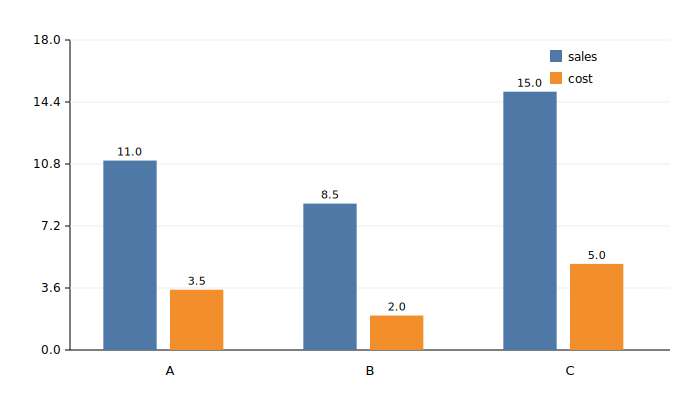

(also saved to /content/mean_values_by_city.svg)

=== Raw result / intermediate info ===

{'messages': [HumanMessage(content='Target column: city\n\nCSV data:\ncity,sales,cost\nA,10,3\nA,12,4\nB,8,2\nB,9,2\nC,15,5\n', additional_kwargs={}, response_metadata={}, id='10fffb32-3266-4495-ab75-8154e4d4eccd'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_irLNTIXBSyt0CmhvR8dNHfQf', 'function': {'arguments': '{"code":"import pandas as pd\\nfrom io import StringIO\\nimport base64\\n\\ncsv_data = \'\'\'city,sales,cost\\nA,10,3\\nA,12,4\\nB,8,2\\nB,9,2\\nC,15,5\'\'\'\\n\\ndf = pd.read_csv(StringIO(csv_data))\\nprint(\'DataFrame shape:\', df.shape)\\nprint(\'Columns:\', list(df.columns))\\nprint()\\nprint(\'Descriptive statistics:\')\\nprint(df.describe(include=\'all\'))\\nprint()\\n\\n# Group means by target if target exists\\nif \'city\' in df.columns:\\n    grouped = df.groupby(\'city\').mean(numeric_only=True)\\n    print(\'Grouped mean numeric values by city:\')\\n    

In [12]:
print("\n=== Chart ===\n")
show_chart(final.get("chart_svg"), final.get("chart_path"))

print("\n=== Raw result / intermediate info ===\n")
print(final.get("intermediate_steps", ""))

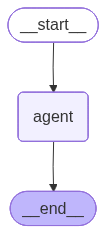

In [13]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))